# Classical Machine Learning: Part 5
## SVM using Radial Basis Function (RBF) Kernel

The RBF Kernel allows the SVM to create non-linear decision boundaries. Instead of working directly in the original feature space, it implicitly maps data into a higher-dimensional space where separation becomes easier. It is generally used in image classification and general purpose datasets when the shape of the boundary is unsure.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, classification_report

np.random.seed(42)

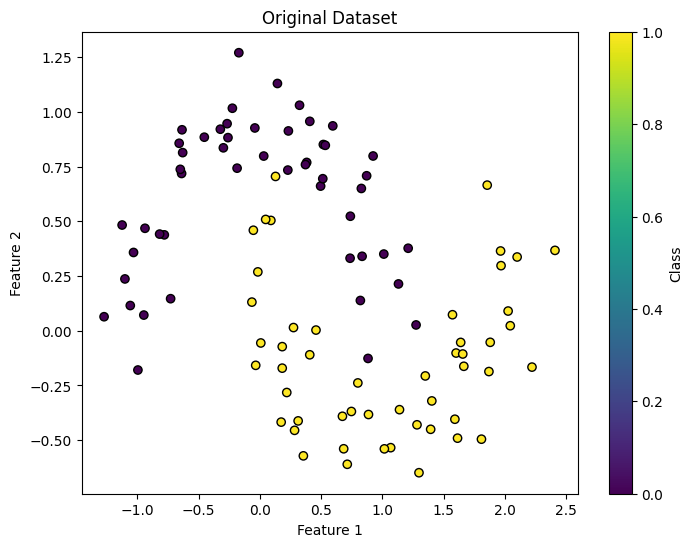

In [2]:
# Generating a non-linearly separabale dataset
X,y=make_moons(noise=0.15, random_state=42)

# Visualizing the dataset
plt.figure(figsize=(8,6))
plt.scatter(X[:,0],X[:,1], c=y, cmap='viridis', edgecolors='k')
plt.title('Original Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Class')
plt.show()

In [3]:
# Create an SVM classifier with RBF (Radial Basis Function) Kernel
# We use a pipeline first to standardize data (important for SVM classification)
# Then apply the SVM with RBF kernel
rbf_svm=make_pipeline(StandardScaler(), SVC(kernel='rbf',gamma='scale'))

rbf_svm.fit(X,y)
print('Model trained successfully!')

Model trained successfully!


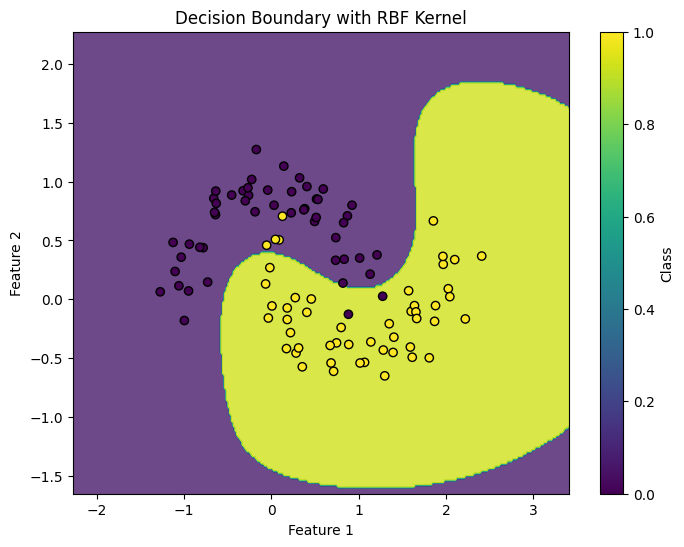

In [4]:
def plot_data(model, X, y):
    h=0.02 # Step size for the mesh grid

    x_min, x_max=X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max=X[:,1].min()-1, X[:,1].max()+1
    xx, yy=np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    Z=model.predict(np.c_[xx.ravel(),yy.ravel()]) # Make predictions
    Z=Z.reshape(xx.shape)

    # Plot the decision boundary and data points
    plt.figure(figsize=(8,6))
    plt.contourf(xx, yy, Z, alpha=0.8, cmap='viridis')
    plt.scatter(X[:,0],X[:,1], c=y, edgecolors='k', marker='o', cmap='viridis')
    plt.title('Decision Boundary with RBF Kernel')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.colorbar(label='Class')
    plt.show()

plot_data(rbf_svm, X, y)

In [5]:
# Training the dataset
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.25, random_state=66)

rbf_svm.fit(X_train, y_train)

y_pred=rbf_svm.predict(X_test)

accuracy=accuracy_score(y_test, y_pred)
print(f'Model Accuracy: {accuracy:.4f}')

print('\nClassification Report:')
print(classification_report(y_test,y_pred))

Model Accuracy: 0.9600

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.97        19
           1       0.86      1.00      0.92         6

    accuracy                           0.96        25
   macro avg       0.93      0.97      0.95        25
weighted avg       0.97      0.96      0.96        25



In [6]:
# Comparison with Linear Kernel
linear_svm=make_pipeline(StandardScaler(), SVC(kernel='linear'))
linear_svm.fit(X_train, y_train)
y_linear_pred=linear_svm.predict(X_test)

print(f'Linear SVM Model Accuracy: {accuracy_score(y_test, y_linear_pred):.4f}')
print('\nClassification Report:')
print(classification_report(y_test,y_linear_pred))

Linear SVM Model Accuracy: 0.8800

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.89      0.92        19
           1       0.71      0.83      0.77         6

    accuracy                           0.88        25
   macro avg       0.83      0.86      0.84        25
weighted avg       0.89      0.88      0.88        25



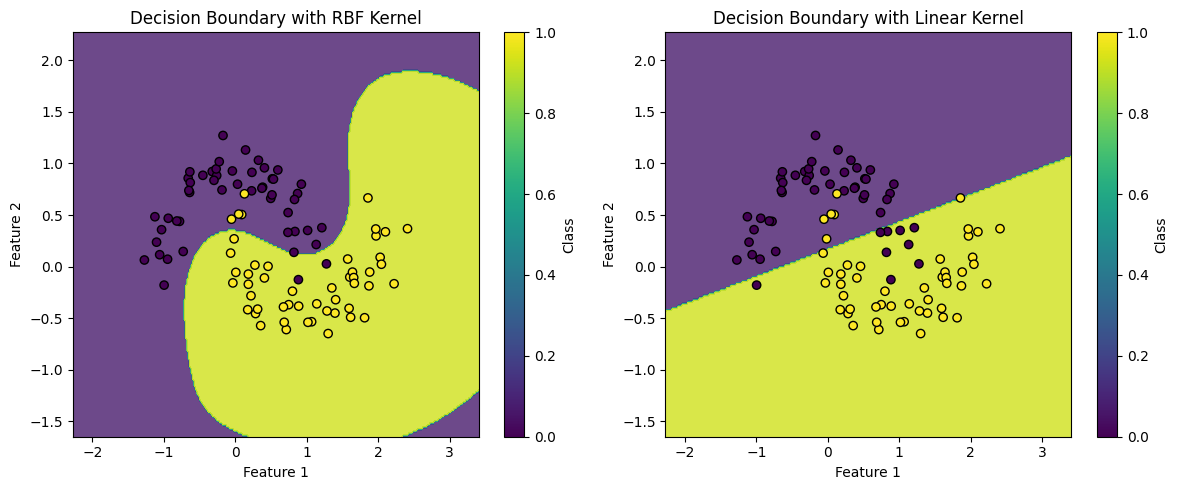

In [7]:
plt.figure(figsize=(12,5))

# Subplot for RBF Kernel
plt.subplot(1,2,1)
h=0.02
x_min, x_max=X[:,0].min()-1, X[:,0].max()+1
y_min, y_max=X[:,1].min()-1, X[:,1].max()+1
xx, yy=np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z=rbf_svm.predict(np.c_[xx.ravel(), yy.ravel()])
Z=Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.8, cmap='viridis')
plt.scatter(X[:,0],X[:,1], c=y, edgecolors='k', marker='o', cmap='viridis')
plt.title('Decision Boundary with RBF Kernel')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Class')

# Subplot for Linear Kernel
plt.subplot(1,2,2)
Z=linear_svm.predict(np.c_[xx.ravel(), yy.ravel()])
Z=Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.8, cmap='viridis')
plt.scatter(X[:,0],X[:,1], c=y, edgecolors='k', marker='o', cmap='viridis')
plt.title('Decision Boundary with Linear Kernel')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Class')

plt.tight_layout()
plt.show()